# A small estimation-to-design example

This notebook uses the Rooney--Biegler biochemical oxygen demand (BOD) model as a compact introduction to `parmest` and Pyomo.DoE.

By the end, you will be able to:

* label a Pyomo model as an `Experiment`;
* estimate parameters and a local covariance matrix;
* convert covariance into prior Fisher information; and
* choose the next measurement time with Pyomo.DoE.

The larger reaction-kinetics tutorials use the same workflow with dynamic models and more parameters.

In [1]:
import sys

if "google.colab" in sys.modules:
    !wget -q "https://raw.githubusercontent.com/ndcbe/optimization/main/notebooks/helper.py"
    import helper
    helper.easy_install()
else:
    sys.path.insert(0, "../")
    import helper

helper.set_plotting_style()

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyomo.environ as pyo
from pyomo.contrib.doe import DesignOfExperiments, ObjectiveLib
from pyomo.contrib.parmest.experiment import Experiment
from pyomo.contrib.parmest.parmest import Estimator

## Model and observations

The response model is

$$
y(t;\theta)=\theta_1\left(1-\exp(-\theta_2t)\right),
$$

where:

* $\theta_1$ is the long-time asymptote;
* $\theta_2$ is the approach rate; and
* $t$ is the measurement time.

We assume independent measurement noise with known standard deviation $\sigma=1$. In Pyomo's experiment suffix, `measurement_error` means **standard deviation**, not variance or weight.

In [3]:
data = pd.DataFrame(
    {
        "hour": [1, 2, 3, 4, 5, 7],
        "y": [8.3, 10.3, 19.0, 16.0, 15.6, 19.8],
    }
)
data

,hour,y
0,1,8.3
1,2,10.3
2,3,19.0
3,4,16.0
4,5,15.6
5,7,19.8


## Label one experiment

Pyomo's `Experiment` abstraction uses four local suffixes:

| Suffix | Role in this example |
|---|---|
| `experiment_outputs` | measured response and observed value |
| `unknown_parameters` | parameters and nominal values |
| `measurement_error` | response standard deviation |
| `experiment_inputs` | candidate measurement time |

`parmest` uses the first three. Pyomo.DoE also needs `experiment_inputs`.

In [4]:
class BODExperiment(Experiment):
    def __init__(
        self, data, measurement_standard_deviation=1.0, theta=None, design_bounds=(0, 10)
    ):
        self.data = dict(data)
        self.measurement_standard_deviation = measurement_standard_deviation
        self.design_bounds = design_bounds
        self.theta = theta or {"asymptote": 15.0, "rate_constant": 0.5}
        self.model = None

    def create_model(self):
        m = self.model = pyo.ConcreteModel()
        m.asymptote = pyo.Var(initialize=self.theta["asymptote"])
        m.rate_constant = pyo.Var(initialize=self.theta["rate_constant"])
        m.asymptote.fix()
        m.rate_constant.fix()

        m.hour = pyo.Var(initialize=self.data["hour"], bounds=self.design_bounds)
        m.hour.fix()
        m.y = pyo.Var(initialize=max(self.data["y"], 1e-3), domain=pyo.PositiveReals)
        m.response = pyo.Constraint(
            expr=m.y == m.asymptote * (1 - pyo.exp(-m.rate_constant * m.hour))
        )

    def label_model(self):
        m = self.model
        m.experiment_outputs = pyo.Suffix(direction=pyo.Suffix.LOCAL)
        m.experiment_outputs.update([(m.y, self.data["y"])])

        m.unknown_parameters = pyo.Suffix(direction=pyo.Suffix.LOCAL)
        m.unknown_parameters.update(
            (parameter, pyo.value(parameter))
            for parameter in [m.asymptote, m.rate_constant]
        )

        m.measurement_error = pyo.Suffix(direction=pyo.Suffix.LOCAL)
        m.measurement_error.update(
            [(m.y, self.measurement_standard_deviation)]
        )

        m.experiment_inputs = pyo.Suffix(direction=pyo.Suffix.LOCAL)
        m.experiment_inputs.update([(m.hour, self.data["hour"])])

    def get_labeled_model(self):
        if self.model is None:
            self.create_model()
            self.label_model()
        return self.model

## Estimate the parameters

Create one experiment per row. The weighted sum of squared errors divides each residual by its measurement standard deviation before squaring.

Covariance estimation needs more experiments than unknown parameters. Two observations could interpolate two parameters, but they cannot support the covariance needed for the next step.

In [5]:
experiments = [BODExperiment(row) for row in data.to_dict("records")]
estimator = Estimator(experiments, obj_function="SSE_weighted")

weighted_sse, theta = estimator.theta_est()
covariance = estimator.cov_est(method="reduced_hessian")

standard_deviation = np.sqrt(np.diag(covariance))
correlation = covariance / np.outer(standard_deviation, standard_deviation)

print(f"Weighted SSE: {weighted_sse:.6f}")
print("Parameters:", theta)
print("Covariance:\n", covariance)
print("Correlation:\n", correlation)

assert np.isclose(theta["asymptote"], 19.1426, rtol=2e-4)
assert np.isclose(theta["rate_constant"], 0.53109, rtol=2e-4)

Weighted SSE: 2.165856
Parameters: {'asymptote': 19.142575284772914, 'rate_constant': 0.531091377067967}
Covariance:
                asymptote  rate_constant
asymptote       0.947415      -0.065445
rate_constant  -0.065445       0.006244
Correlation:
                asymptote  rate_constant
asymptote       1.000000      -0.850885
rate_constant  -0.850885       1.000000


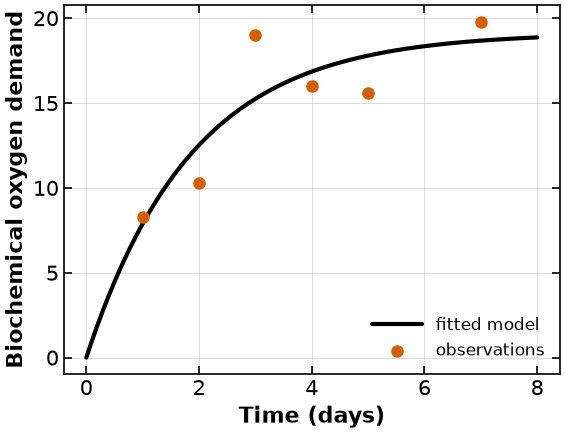

In [6]:
t_plot = np.linspace(0, 8, 250)
y_fit = theta["asymptote"] * (1 - np.exp(-theta["rate_constant"] * t_plot))

plt.plot(t_plot, y_fit, color="black", label="fitted model")
plt.scatter(data["hour"], data["y"], color="#D55E00", label="observations", zorder=3)
plt.xlabel("Time (days)")
plt.ylabel("Biochemical oxygen demand")
plt.grid(True)
plt.legend()
plt.show()

## From covariance to experimental design

The covariance becomes prior information:

$$\mathbf{F}_{\mathrm{prior}}=\mathbf{V}_{\theta}^{-1}.$$

For one new measurement with standard deviation 1,

$$
\mathbf{F}_{\mathrm{new}}(t)=\mathbf{F}_{\mathrm{prior}}+
\mathbf{q}(t)\mathbf{q}(t)^\mathsf{T},
$$

with sensitivity vector

$$
\mathbf{q}(t)=
\begin{bmatrix}
1-\exp(-\theta_2t)\\
\theta_1t\exp(-\theta_2t)
\end{bmatrix}.
$$

The two sensitivity components favor different time regions. A useful design balances the new direction against information already contained in the prior.

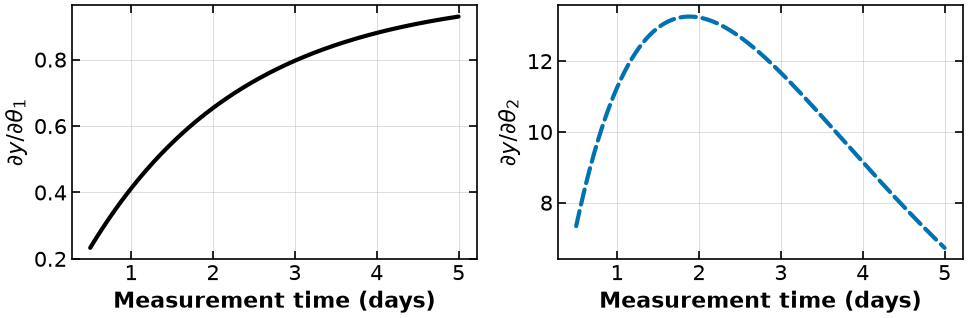

In [7]:
t_design = np.linspace(0.5, 5, 300)
q_asymptote = 1 - np.exp(-theta["rate_constant"] * t_design)
q_rate = theta["asymptote"] * t_design * np.exp(-theta["rate_constant"] * t_design)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(t_design, q_asymptote, color="black")
axes[0].set_ylabel(r"$\partial y/\partial\theta_1$")
axes[1].plot(t_design, q_rate, color="#0072B2", linestyle="--")
axes[1].set_ylabel(r"$\partial y/\partial\theta_2$")
for ax in axes:
    ax.set_xlabel("Measurement time (days)")
    ax.grid(True)
plt.tight_layout()
plt.show()

## Optimize the next measurement

Pyomo 6.10 configures the objective and solver behavior in the `DesignOfExperiments` constructor. `run_doe()` performs the optimization and stores the summary in `doe.results`.

The bounds in `BODExperiment` restrict the new measurement to 0.5--5 days.

In [8]:
prior_fim = np.linalg.inv(covariance)
design_experiment = BODExperiment(
    {"hour": 2.0, "y": 10.0},
    measurement_standard_deviation=1.0,
    theta=dict(theta),
    design_bounds=(0.5, 5.0),
)

doe = DesignOfExperiments(
    experiment=design_experiment,
    fd_formula="central",
    step=1e-3,
    objective_option=ObjectiveLib.determinant,
    prior_FIM=prior_fim,
    improve_cholesky_roundoff_error=True,
    tee=False,
)
doe.run_doe(model=doe.create_doe_model())

optimal_time = doe.results["Experiment Design"][0]
print(f"D-optimal next measurement: {optimal_time:.6f} days")

D-optimal next measurement: 1.502729 days


## Verify with an independent calculation

For this two-parameter model, a dense grid is cheap. It provides an independent check on the software formulation and local optimizer.

Dense-grid optimum: 1.503500 days
Prior log determinant:   6.417511
Updated log determinant: 6.755141


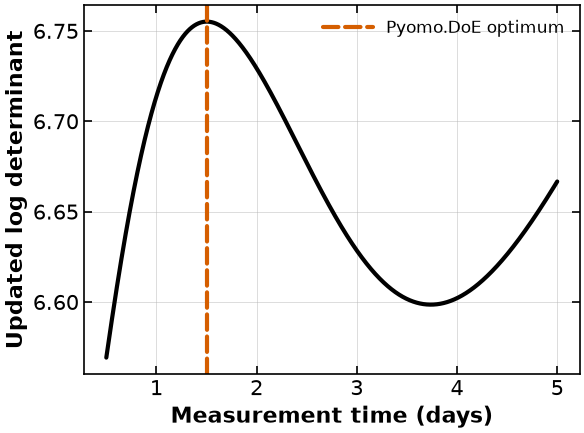

In [9]:
def updated_fim(t):
    sensitivity = np.array(
        [
            1 - np.exp(-theta["rate_constant"] * t),
            theta["asymptote"] * t * np.exp(-theta["rate_constant"] * t),
        ]
    )
    return prior_fim + np.outer(sensitivity, sensitivity)


grid = np.linspace(0.5, 5, 2001)
grid_logdet = np.array([np.linalg.slogdet(updated_fim(t))[1] for t in grid])
grid_time = grid[np.argmax(grid_logdet)]

print(f"Dense-grid optimum: {grid_time:.6f} days")
print(f"Prior log determinant:   {np.linalg.slogdet(prior_fim)[1]:.6f}")
print(f"Updated log determinant: {grid_logdet.max():.6f}")
assert abs(optimal_time - grid_time) < 0.02

plt.plot(grid, grid_logdet, color="black")
plt.axvline(optimal_time, color="#D55E00", linestyle="--", label="Pyomo.DoE optimum")
plt.xlabel("Measurement time (days)")
plt.ylabel("Updated log determinant")
plt.grid(True)
plt.legend()
plt.show()

## Key takeaways

* Parameter estimation turns measurements into fitted parameters and an uncertainty description.
* The inverse covariance is prior Fisher information for the next design.
* Experimental design asks where a new measurement adds information not already supplied by the prior.
* FIM designs are local: different nominal parameters, noise models, bounds, or priors can change the answer.
* Small examples permit independent checks. Use them before trusting a larger dynamic design.